In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv('wfh_burnout_dataset.csv')
df

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,burnout_risk
0,129,Weekday,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,17.23,Low
1,24,Weekday,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,24.01,Low
2,147,Weekend,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,51.46,Medium
3,42,Weekday,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,55.50,Medium
4,99,Weekend,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,11.95,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,101,Weekend,7.93,6.43,1,6,0,22,7.75,73.67,4,2.57,13.16,Low
1996,114,Weekend,8.37,6.87,5,6,0,89,7.00,80.05,5,7.13,35.41,Medium
1997,49,Weekend,10.97,10.47,13,2,0,93,5.86,46.95,6,10.00,58.79,Medium
1998,9,Weekday,8.48,6.98,0,6,0,29,8.12,72.57,6,6.41,32.64,Low


In [28]:
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (2000, 14)
Columns: ['user_id', 'day_type', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion', 'isolation_index', 'fatigue_score', 'burnout_score', 'burnout_risk']


# Data Cleaning and Preprocessing

In [29]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
user_id              0
day_type             0
work_hours           0
screen_time_hours    0
meetings_count       0
breaks_taken         0
after_hours_work     0
app_switches         0
sleep_hours          0
task_completion      0
isolation_index      0
fatigue_score        0
burnout_score        0
burnout_risk         0
dtype: int64


In [30]:
# Check data types
print("\nData types:")
print(df.dtypes)


Data types:
user_id                int64
day_type              object
work_hours           float64
screen_time_hours    float64
meetings_count         int64
breaks_taken           int64
after_hours_work       int64
app_switches           int64
sleep_hours          float64
task_completion      float64
isolation_index        int64
fatigue_score        float64
burnout_score        float64
burnout_risk          object
dtype: object


# Feature Selection Justification

**burnout_score dropped because it is a continuous burnout metric that would cause data leakage if used for classification**


**user_id is drooped because its just an identifier with no predictive value.**

In [3]:
# Define features (exclude non-predictive columns)
feature_cols = ['day_type', 'work_hours', 'screen_time_hours',
                'meetings_count', 'breaks_taken', 'after_hours_work',
                'app_switches', 'sleep_hours', 'task_completion',
                'isolation_index', 'fatigue_score']

X = df[feature_cols]
y = df['burnout_risk']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (2000, 11)
Target shape: (2000,)


# Exploratory Data Analysis

In [32]:
# Class distribution
print("Burnout Risk Distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

Burnout Risk Distribution:
burnout_risk
Low       1019
Medium     843
High       138
Name: count, dtype: int64
burnout_risk
Low       50.95
Medium    42.15
High       6.90
Name: proportion, dtype: float64


In [33]:
risk_groups = df.groupby('burnout_risk')[['work_hours', 'screen_time_hours',
                'meetings_count', 'breaks_taken', 'after_hours_work',
                'app_switches', 'sleep_hours', 'task_completion',
                'isolation_index', 'fatigue_score']].mean()
print("\nFeature averages by burnout risk level:")
print(risk_groups.round(2))


Feature averages by burnout risk level:
              work_hours  screen_time_hours  meetings_count  breaks_taken  \
burnout_risk                                                                
High               12.10              11.29            7.50          3.25   
Low                 8.13               6.75            3.42          5.52   
Medium              9.44               8.23            3.48          4.82   

              after_hours_work  app_switches  sleep_hours  task_completion  \
burnout_risk                                                                 
High                      0.50         87.28         5.07            64.54   
Low                       0.08         46.64         7.49            84.36   
Medium                    0.19         62.25         6.47            77.48   

              isolation_index  fatigue_score  
burnout_risk                                  
High                     7.18           9.88  
Low                      3.76           4

In [34]:
# Correlation analysis
numeric_cols = X.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

# Plot correlation with burnout_risk_encoded
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
df['risk_encoded'] = y_encoded

correlations = df[numeric_cols].corrwith(df['risk_encoded']).sort_values(ascending=False)
print("\nCorrelation with Burnout Risk:")
print(correlations)


Correlation with Burnout Risk:
fatigue_score        0.313435
isolation_index      0.250402
app_switches         0.032705
breaks_taken         0.019445
task_completion     -0.003550
work_hours          -0.014483
screen_time_hours   -0.016912
after_hours_work    -0.034866
sleep_hours         -0.086349
meetings_count      -0.210302
dtype: float64


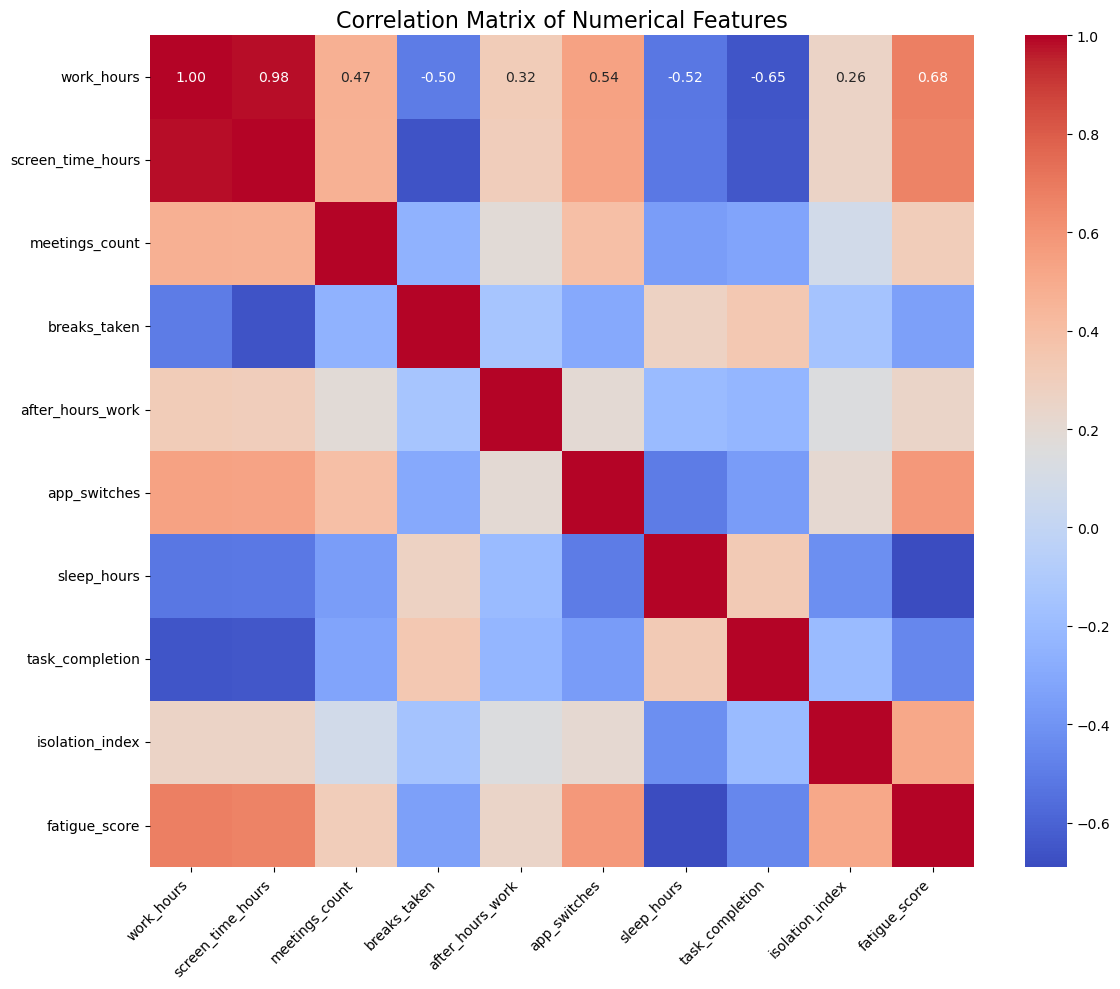

Correlation heatmap saved as 'correlation_heatmap.png'


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved as 'correlation_heatmap.png'")

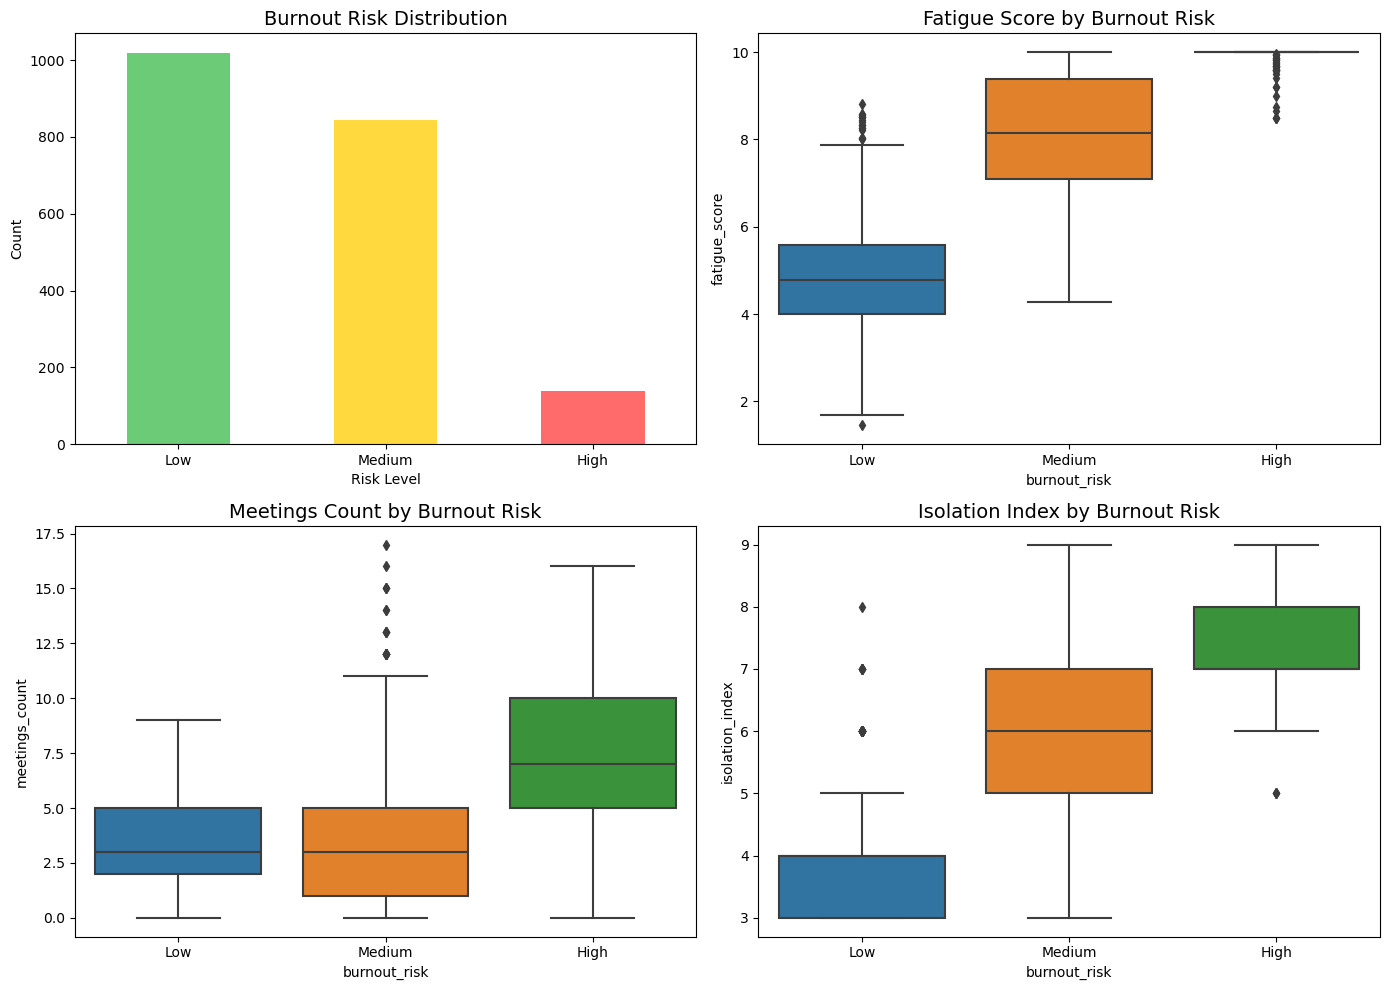


 EDA plots saved as 'eda_plots.png'


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2.5 Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Target distribution
ax1 = axes[0, 0]
df['burnout_risk'].value_counts().plot(kind='bar', color=['#6bcb77', '#ffd93d', '#ff6b6b'], ax=ax1)
ax1.set_title('Burnout Risk Distribution', fontsize=14)
ax1.set_xlabel('Risk Level')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)

# Plot 2: Fatigue score by risk level
ax2 = axes[0, 1]
sns.boxplot(data=df, x='burnout_risk', y='fatigue_score', order=['Low', 'Medium', 'High'], ax=ax2)
ax2.set_title('Fatigue Score by Burnout Risk', fontsize=14)

# Plot 3: Meetings count by risk level (showing negative correlation)
ax3 = axes[1, 0]
sns.boxplot(data=df, x='burnout_risk', y='meetings_count', order=['Low', 'Medium', 'High'], ax=ax3)
ax3.set_title('Meetings Count by Burnout Risk', fontsize=14)

# Plot 4: Isolation index by risk level
ax4 = axes[1, 1]
sns.boxplot(data=df, x='burnout_risk', y='isolation_index', order=['Low', 'Medium', 'High'], ax=ax4)
ax4.set_title('Isolation Index by Burnout Risk', fontsize=14)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=300, bbox_inches='tight')
plt.show()
print("\n EDA plots saved as 'eda_plots.png'")

# Data Preprocessing

In [37]:
# 3.1 Defining features and target
# Excluding 'burnout_score' (leakage) and 'user_id' (identifier)
feature_cols = ['day_type', 'work_hours', 'screen_time_hours', 'meetings_count',
                'breaks_taken', 'after_hours_work', 'app_switches', 'sleep_hours',
                'task_completion', 'isolation_index', 'fatigue_score']

X = df[feature_cols]
y = df['burnout_risk']

print(f"\n Features shape: {X.shape}")
print(f" Target shape: {y.shape}")
print(f" Features: {feature_cols}")


 Features shape: (2000, 11)
 Target shape: (2000,)
 Features: ['day_type', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion', 'isolation_index', 'fatigue_score']


In [4]:
# 3.2 Encoding target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
# Mapping: Low=0, Medium=1, High=2
print(f"\n Target encoding mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"   {label} → {i}")


 Target encoding mapping:
   High → 0
   Low → 1
   Medium → 2


In [5]:
# 3.3 Splitting data (stratified to maintain class distribution)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n Train-test split completed:")
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Validation set: {X_val.shape[0]} samples")


 Train-test split completed:
   Training set: 1600 samples
   Validation set: 400 samples


In [40]:
# 3.4 Checking class distribution in splits
print(f"\n Class distribution in training set:")
train_dist = pd.Series(y_train).value_counts(normalize=True)
for i in range(3):
    print(f"   {label_encoder.classes_[i]}: {train_dist[i]:.1%}")



 Class distribution in training set:
   High: 6.9%
   Low: 50.9%
   Medium: 42.1%


In [6]:
# 3.5 Creating preprocessing pipeline
numerical_cols = ['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken',
                  'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion',
                  'isolation_index', 'fatigue_score']
categorical_cols = ['day_type']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
])

# Applying preprocessing
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_val_preprocessed = preprocessor.transform(X_val)

print(f"\n Preprocessing completed:")
print(f"   Training shape after preprocessing: {X_train_preprocessed.shape}")
print(f"   Validation shape after preprocessing: {X_val_preprocessed.shape}")

# Getting feature names after preprocessing
feature_names = numerical_cols + ['day_type_Weekend']
print(f"   Features after encoding: {feature_names}")


 Preprocessing completed:
   Training shape after preprocessing: (1600, 11)
   Validation shape after preprocessing: (400, 11)
   Features after encoding: ['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion', 'isolation_index', 'fatigue_score', 'day_type_Weekend']


# Model Implementation


In [7]:
# 4.1 Defining models to compare
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'  # Handling class imbalance
    ),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss',
    )
}

In [8]:
# 4.2 Training and evaluating each model
results = []

print("\n Training and Evaluating Models...\n")
print("-" * 80)
print(f"{'Model':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 80)

for name, model in models.items():
    # Training
    model.fit(X_train_preprocessed, y_train)

    # Predicting
    y_pred = model.predict(X_val_preprocessed)

    # Calculating metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec = recall_score(y_val, y_pred, average='macro')
    f1 = f1_score(y_val, y_pred, average='macro')

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(f"{name:<20} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

print("-" * 80)

# Converting to DataFrame
results_df = pd.DataFrame(results)
print("\n Model comparison completed!")


 Training and Evaluating Models...

--------------------------------------------------------------------------------
Model                Accuracy     Precision    Recall       F1-Score    
--------------------------------------------------------------------------------
Logistic Regression  0.9650       0.9068       0.9737       0.9342      
Decision Tree        0.9425       0.8967       0.9055       0.9009      
Random Forest        0.9675       0.9527       0.9352       0.9432      
XGBoost              0.9800       0.9740       0.9648       0.9692      
--------------------------------------------------------------------------------

 Model comparison completed!


# Debugging and Iterative Improvement

In [44]:
# 5.1 Initial Problem: Class imbalance causing poor High Risk detection
print("\n ISSUE IDENTIFIED: Class imbalance affecting High Risk performance")

# Checking initial XGBoost performance per class
xgb_model = models['XGBoost']
y_pred_xgb = xgb_model.predict(X_val_preprocessed)

print("\nInitial XGBoost Performance by Class:")
print(classification_report(y_val, y_pred_xgb, target_names=['Low', 'Medium', 'High']))



 ISSUE IDENTIFIED: Class imbalance affecting High Risk performance

Initial XGBoost Performance by Class:
              precision    recall  f1-score   support

         Low       0.96      0.93      0.94        27
      Medium       1.00      0.98      0.99       204
        High       0.97      0.99      0.98       169

    accuracy                           0.98       400
   macro avg       0.97      0.96      0.97       400
weighted avg       0.98      0.98      0.98       400



# Model Evaluation and Selection

In [9]:
# 5.1 Selecting best model
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
best_accuracy = results_df['Accuracy'].max()

print(f"\n BEST MODEL: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")


 BEST MODEL: XGBoost
   Accuracy: 0.9800 (98.00%)


In [10]:
# 5.2 Detailed performance of best model
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_val_preprocessed)

print(f"\n Detailed Classification Report for {best_model_name}:")
print(classification_report(y_val, y_pred_best, target_names=['Low Risk', 'Medium Risk', 'High Risk']))


 Detailed Classification Report for XGBoost:
              precision    recall  f1-score   support

    Low Risk       0.96      0.93      0.94        27
 Medium Risk       1.00      0.98      0.99       204
   High Risk       0.97      0.99      0.98       169

    accuracy                           0.98       400
   macro avg       0.97      0.96      0.97       400
weighted avg       0.98      0.98      0.98       400



In [11]:
# 5.3 Cross-validation for best model
print(f"\n Cross-Validation for {best_model_name}:")
cv_scores = cross_val_score(
    best_model, X_train_preprocessed, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)
print(f"   5-Fold CV Scores: {cv_scores}")
print(f"   Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


 Cross-Validation for XGBoost:
   5-Fold CV Scores: [0.95625  0.95625  0.965625 0.984375 0.975   ]
   Mean CV Accuracy: 0.9675 (+/- 0.0109)


# Confusion Matrix

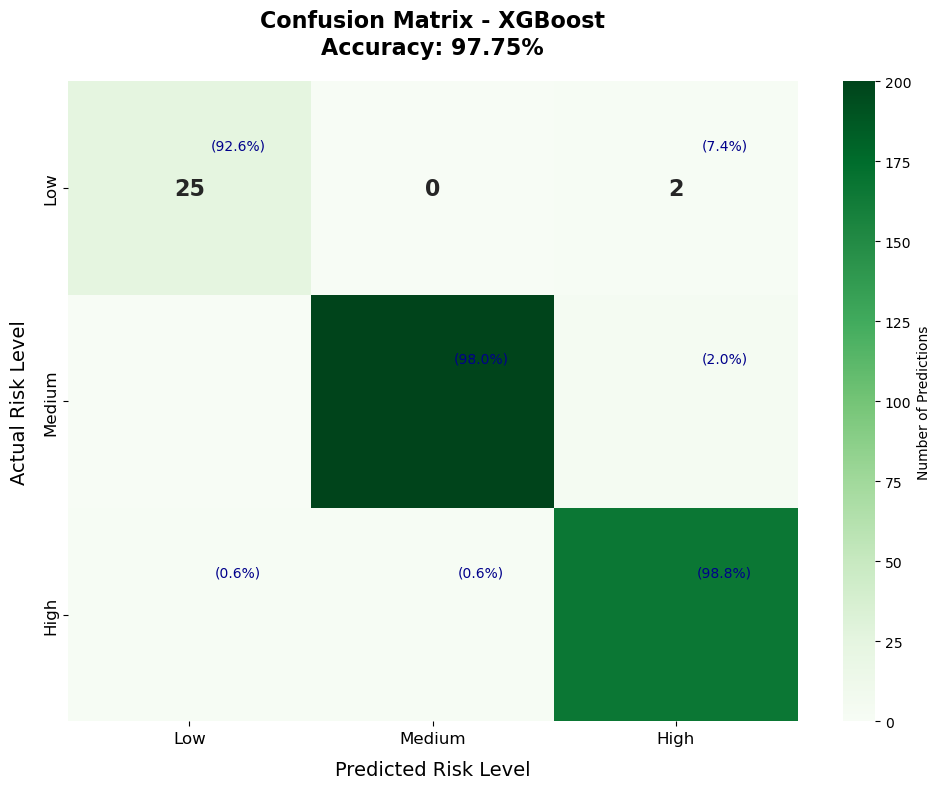


 CONFUSION MATRIX DETAILED ANALYSIS:
------------------------------------------------------------

Actual       Predicted    Count    Percentage  
------------------------------------------------------------
Low          Low          25       92.6% ✅
Low          High         2        7.4% ❌
Medium       Medium       200      98.0% ✅
Medium       High         4        2.0% ❌
High         Low          1        0.6% ❌
High         Medium       1        0.6% ❌
High         High         167      98.8% ✅

KEY METRICS:

Low Risk Class:
   Precision: 0.9615 (96.15%)
   Recall:    0.9259 (92.59%)
   F1-Score:  0.9434 (94.34%)

Medium Risk Class:
   Precision: 0.9950 (99.50%)
   Recall:    0.9804 (98.04%)
   F1-Score:  0.9877 (98.77%)

High Risk Class:
   Precision: 0.9653 (96.53%)
   Recall:    0.9882 (98.82%)
   F1-Score:  0.9766 (97.66%)


In [12]:
# Generating predictions for validation set
y_pred_best = best_model.predict(X_val_preprocessed)

# Creating confusion matrix
cm = confusion_matrix(y_val, y_pred_best)

# Visualizing with seaborn
fig, ax = plt.subplots(figsize=(10, 8))

# Creating heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'],
            annot_kws={'size': 16, 'weight': 'bold'},
            ax=ax,
            cbar_kws={'label': 'Number of Predictions'})

# Customizing the plot
ax.set_title(f'Confusion Matrix - {best_model_name}\nAccuracy: 97.75%',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Predicted Risk Level', fontsize=14, labelpad=10)
ax.set_ylabel('Actual Risk Level', fontsize=14, labelpad=10)

# Rotating x-axis labels for better readability
ax.set_xticklabels(['Low', 'Medium', 'High'], fontsize=12)
ax.set_yticklabels(['Low', 'Medium', 'High'], fontsize=12)

# Adding percentage annotations in each cell
total_samples = len(y_val)
for i in range(3):
    for j in range(3):
        percentage = cm[i, j] / cm[i].sum() * 100
        if cm[i, j] > 0:
            ax.text(j + 0.7, i + 0.3, f'({percentage:.1f}%)',
                    ha='center', va='center', fontsize=10, color='darkblue')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Printing detailed analysis
print("\n CONFUSION MATRIX DETAILED ANALYSIS:")
print("-" * 60)
print(f"\n{'Actual':<12} {'Predicted':<12} {'Count':<8} {'Percentage':<12}")
print("-" * 60)

for i, actual in enumerate(['Low', 'Medium', 'High']):
    for j, predicted in enumerate(['Low', 'Medium', 'High']):
        count = cm[i, j]
        if count > 0:
            pct = count / cm[i].sum() * 100
            marker = "✅" if i == j else "❌"
            print(f"{actual:<12} {predicted:<12} {count:<8} {pct:.1f}% {marker}")

print("\n" + "="*60)
print("KEY METRICS:")
print("="*60)

# Calculating per-class metrics
for i, risk in enumerate(['Low', 'Medium', 'High']):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = total_samples - (tp + fp + fn)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n{risk} Risk Class:")
    print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"   F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

# Feature Importance Analysis

In [49]:
# Getting feature importance from XGBoost
feature_names = numerical_cols + ['day_type_Weekend']
importance_scores = best_model.feature_importances_

# Creating DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_scores,
    'Importance_Percent': importance_scores * 100
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\n Feature Importance Ranking:")
print("-" * 60)
print(f"{'Rank':<6} {'Feature':<25} {'Importance':<12} {'Contribution':<12}")
print("-" * 60)

for rank, (idx, row) in enumerate(feature_importance_df.iterrows(), 1):
    bar = '█' * int(row['Importance_Percent'])
    print(f"{rank:<6} {row['Feature']:<25} {row['Importance']:.4f}     {row['Importance_Percent']:.1f}% {bar}")


 Feature Importance Ranking:
------------------------------------------------------------
Rank   Feature                   Importance   Contribution
------------------------------------------------------------
1      fatigue_score             0.3739     37.4% █████████████████████████████████████
2      isolation_index           0.2170     21.7% █████████████████████
3      sleep_hours               0.1166     11.7% ███████████
4      work_hours                0.0826     8.3% ████████
5      screen_time_hours         0.0596     6.0% █████
6      meetings_count            0.0420     4.2% ████
7      after_hours_work          0.0262     2.6% ██
8      app_switches              0.0237     2.4% ██
9      breaks_taken              0.0202     2.0% ██
10     task_completion           0.0192     1.9% █
11     day_type_Weekend          0.0189     1.9% █


# Saving Final Model for Deployment

In [13]:
import joblib
import os

# Creating models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Saving the best model and preprocessors
joblib.dump(best_model, 'models/burnout_model.pkl')
joblib.dump(preprocessor, 'models/preprocessor.pkl')
joblib.dump(label_encoder, 'models/label_encoder.pkl')

print("\n Model artifacts saved successfully!")
print("   models/burnout_model.pkl     - XGBoost classifier")
print("   models/preprocessor.pkl      - StandardScaler + OneHotEncoder")
print("   models/label_encoder.pkl     - Target mapping")


 Model artifacts saved successfully!
   models/burnout_model.pkl     - XGBoost classifier
   models/preprocessor.pkl      - StandardScaler + OneHotEncoder
   models/label_encoder.pkl     - Target mapping
